# Experiment Report — Event-Driven AI Financial Advisor

Tracks every training + backtest run logged in `data/4_experiments/experiment_log.csv`,
using a two-tier evaluation approach, fixed before the first run and kept
consistent across every later change so results stay comparable:

- **Tier 1** (`accuracy`, `precision`) — fast per-step sanity check on model quality
- **Tier 2** (`total_return`, `win_rate`, `max_drawdown`, `sharpe`) — the true
  cross-step gate, computed from actual backtested trade outcomes

Re-run this notebook after every new run is logged. Fill in the **Stage** sections
at the bottom as each experiment step is completed — that narrative is what
goes into the report's Evaluation chapter.


In [1]:
import sys, os

# Jupyter's cwd is this notebook's own folder, not the project root - chdir
# so the data/ and src/ relative paths used throughout the codebase resolve
# the same way here as they do when a script is run from the project root.
PROJECT_ROOT = os.path.abspath("..")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
from src.utils import experiment_log, experiment_charts as ec

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 140)


## All runs

Full log, with `config_json` expanded into its own columns. Runs are labeled
`Run 1, Run 2, ...` in chronological order rather than shown by `run_id` -
`run_id` embeds the real timestamp each run was created at (see
`experiment_log.new_run_id`), which isn't something the report needs to show.


In [2]:
log_df = experiment_log.load_experiment_log()
ec.report_table(log_df)


,Run_Label,config_json,accuracy,precision,total_return,win_rate,max_drawdown,sharpe,train_accuracy,train_precision,...,config_reg_lambda,config_scale_pos_weight,config_max_depth,config_min_child_weight,config_subsample,config_colsample_bytree,config_n_estimators,config_early_stopping_rounds,config_return_col,config_n_seeds
0,Run 1,{},0.568204,0.529769,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Run 2,"{""universe"": ""current_only"", ""n_rows"": 42575}",0.575014,0.521599,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Run 3,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875}",0.563360,0.521202,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Run 4,{},0.563360,0.521202,-0.107299,0.499794,-0.767663,0.378406,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Run 5,"{""universe"": ""current_only"", ""n_rows"": 42575}",0.575014,0.521599,5.948502,0.528691,-0.426243,1.995847,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Run 6,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875}",0.563360,0.521202,-0.107299,0.499794,-0.767663,0.378406,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Run 7,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""max_position_weight"": null}",0.563360,0.521202,-0.107299,0.499794,-0.767663,0.378406,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Run 8,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""max_position_weight"": 0.2}",0.563360,0.521202,0.056162,0.499794,-0.436418,0.263148,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Run 9,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""max_position_weight"": 0.1}",0.563360,0.521202,0.014998,0.499794,-0.271251,0.152880,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Run 10,"{""universe"": ""all_incl_delisted"", ""n_rows"": 51875, ""spike_threshold"": 0.05, ""max_position_weight"": 0.2}",0.813938,0.336634,0.096135,0.534653,-0.129952,0.764668,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## What changed between runs

For each run after the first: which config key(s) changed vs. the immediately
preceding run, and how much each metric moved as a result. This is the
"what changed → what happened" record for the report — no need to
hand-track it separately.


In [3]:
diff_df = ec.diff_config_between_runs(log_df)
diff_df


,run_label,prev_run_label,config_changed,accuracy_delta,precision_delta,total_return_delta,win_rate_delta,max_drawdown_delta,sharpe_delta
0,Run 2,Run 1,"{'universe': (nan, 'current_only'), 'n_rows': (nan, 42575.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan)}",0.006809,-0.008170,NaN,NaN,NaN,NaN
1,Run 3,Run 2,"{'universe': ('current_only', 'all_incl_delisted'), 'n_rows': (42575.0, 51875.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan)}",-0.011654,-0.000397,NaN,NaN,NaN,NaN
2,Run 4,Run 3,"{'universe': ('all_incl_delisted', nan), 'n_rows': (51875.0, nan), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan)}",0.000000,0.000000,NaN,NaN,NaN,NaN
3,Run 5,Run 4,"{'universe': (nan, 'current_only'), 'n_rows': (nan, 42575.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan)}",0.011654,0.000397,6.055801,0.028897,0.341420,1.617441
4,Run 6,Run 5,"{'universe': ('current_only', 'all_incl_delisted'), 'n_rows': (42575.0, 51875.0), 'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'colsample_bytree': (nan, nan), 'n_estimators': (nan, nan), 'early_stopping_rounds': (nan, nan), 'return_col': (nan, nan), 'n_seeds': (nan, nan)}",-0.011654,-0.000397,-6.055801,-0.028897,-0.341420,-1.617441
5,Run 7,Run 6,"{'max_position_weight': (nan, nan), 'spike_threshold': (nan, nan), 'labeling': (nan, nan), 'take_profit': (nan, nan), 'stop_loss': (nan, nan), 'max_holding_days': (nan, nan), 'features': (nan, nan), 'experiment': (nan, nan), 'label': (nan, nan), 'reg_alpha': (nan, nan), 'reg_lambda': (nan, nan), 'scale_pos_weight': (nan, nan), 'max_depth': (nan, nan), 'min_child_weight': (nan, nan), 'subsample': (nan, nan), 'c

## Tier 1 — model-quality trend

Valid only *within* a step where the label definition hasn't changed.

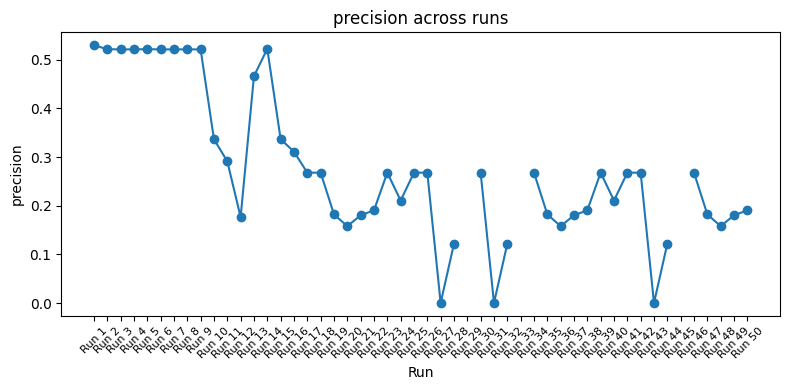

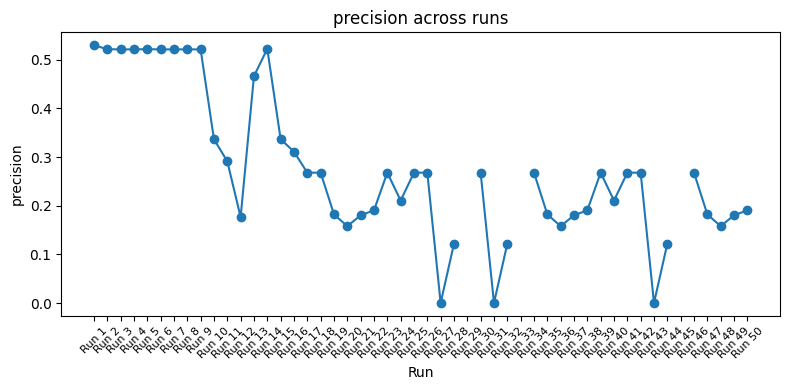

In [4]:
ec.plot_metric_trend("precision", log_df=log_df)


## Tier 2 — financial trend

The cross-step gate — comparable across every step of the sweep, regardless of internal model/label changes.

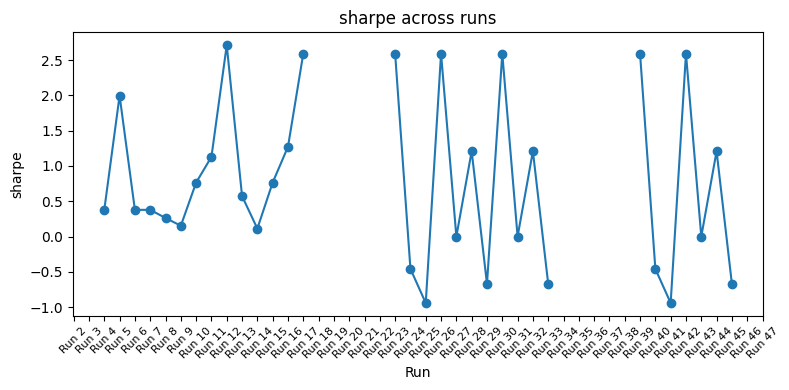

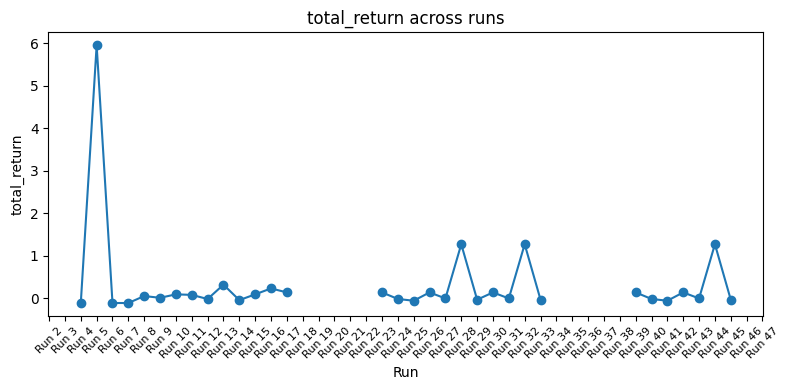

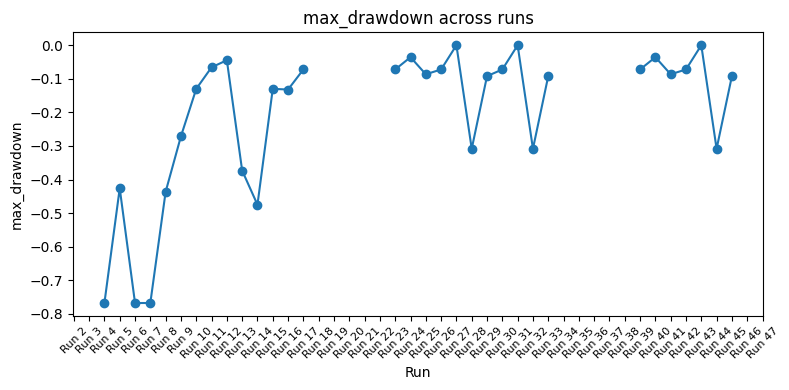

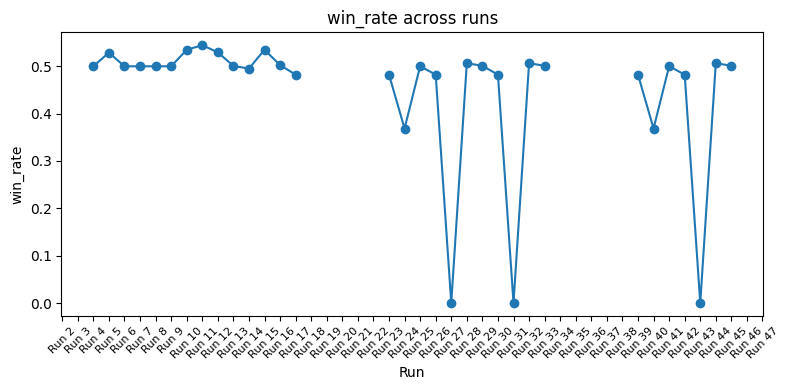

In [5]:
for metric in ["sharpe", "total_return", "max_drawdown", "win_rate"]:
    ec.plot_metric_trend(metric, log_df=log_df)


## Precision vs. Sharpe

Did a Tier 1 (precision) improvement actually pay off at Tier 2 (Sharpe)? A run that
moves up-and-right improved on both; up-and-left means Tier 1 improved but the
financial result got worse — a sign the model is overfitting to the label, not
learning something that survives contact with real trade outcomes.


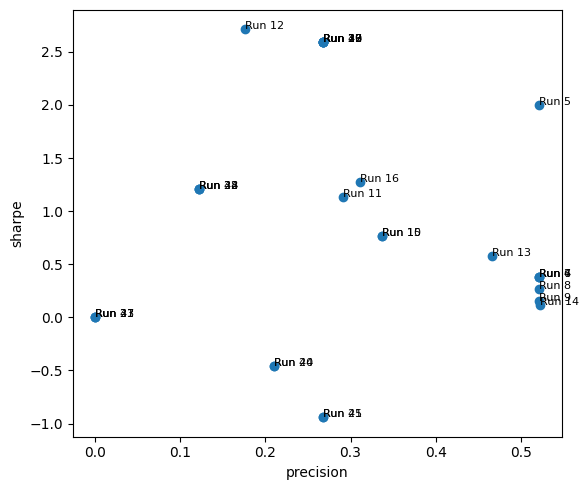

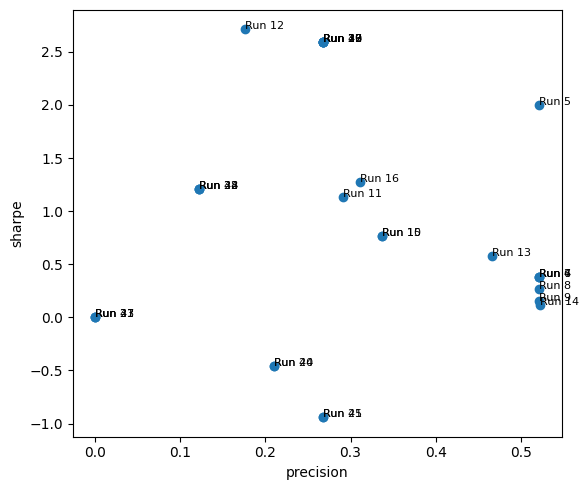

In [6]:
ec.plot_tradeoff("precision", "sharpe", log_df=log_df)


## Best runs so far

Top runs ranked by Sharpe (the primary Tier 2 metric), Max Drawdown as the
hard constraint — a new run only replaces the current champion if Sharpe
improves *and* drawdown doesn't breach the limit.


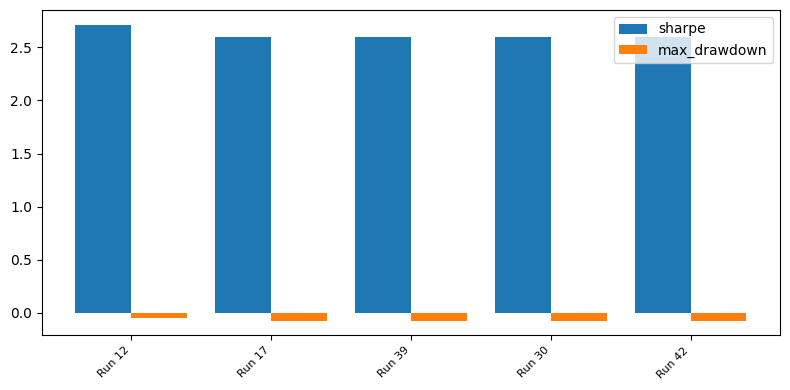

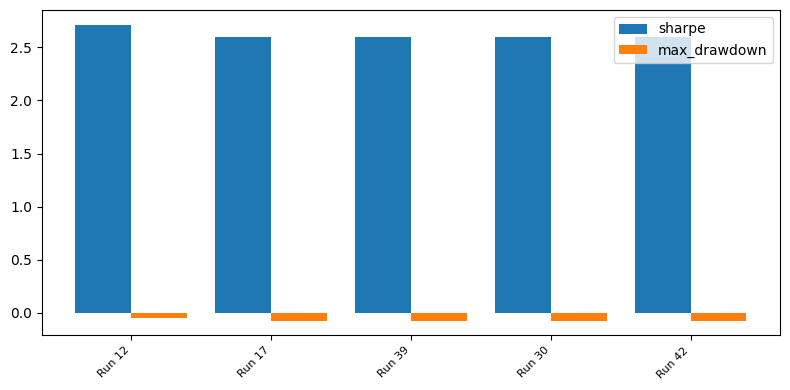

In [7]:
ec.plot_metric_comparison(["sharpe", "max_drawdown"], log_df=log_df, top_n=5)


In [8]:
import sys as _sys
_sys.path.insert(0, os.path.join(PROJECT_ROOT, "scripts"))

## Regularisation, tree-complexity and early stopping — does it close the overfitting gap?

Three follow-up experiments below, run after the sweep above, in response to
code review feedback on the draft report. This one and the next also compute
metrics (payoff stats, outlier robustness, a limit-order execution variant)
that don't fit `experiment_log.csv`'s fixed schema, so they're computed fresh
by re-running the code rather than stored anywhere else — re-run this section
before writing the report from it, rather than trusting stale numbers copied
into prose.

**Hypothesis.** Section [5.5] diagnosed a persistent train/test precision gap
(0.536–0.678). Section [5.6] scoped three untested interventions — regularisation
(`reg_alpha`/`reg_lambda`/`scale_pos_weight`), tree-complexity limits
(`max_depth`/`min_child_weight`/`subsample`), and early stopping on a
validation split — as the direct next step. Does applying them actually
close the gap *and* improve real (test-set) precision, or only make train
precision converge toward test precision without a genuine improvement?


In [9]:
import experiment_overfitting_gap
experiment_overfitting_gap.main()


Training set class balance: 4354 positive / 38094 negative (scale_pos_weight=8.749)

baseline                                       test_precision=0.2679  train_precision=0.9464  gap=0.6785
regularised                                    test_precision=0.1822  train_precision=0.3418  gap=0.1596
tree_complexity                                test_precision=0.1579  train_precision=0.6837  gap=0.5258
regularised+tree_complexity                    test_precision=0.1802  train_precision=0.2039  gap=0.0236
regularised+tree_complexity+early_stopping     test_precision=0.1905  train_precision=0.1949  gap=0.0044

--- Summary (gap vs baseline) ---
baseline                                       gap=0.6785  (+0.0000 vs baseline)
regularised                                    gap=0.1596  (-0.5190 vs baseline)
tree_complexity                                gap=0.5258  (-0.1527 vs baseline)
regularised+tree_complexity                    gap=0.0236  (-0.6549 vs baseline)
regularised+tree_complexity+ear

**Result and interpretation.**

*Tier 1 (precision/gap)*

| Config | Test precision | Train precision | Gap |
|---|---|---|---|
| Baseline (current production) | 0.268 | 0.946 | 0.679 |
| + regularised (reg_alpha/reg_lambda/scale_pos_weight) | 0.182 | 0.342 | 0.160 |
| + tree-complexity (max_depth=3, min_child_weight=5, subsample=0.7) | 0.158 | 0.684 | 0.526 |
| + regularised + tree-complexity | 0.180 | 0.204 | 0.024 |
| + all three + early stopping | 0.191 | 0.195 | **0.004** |

*Tier 2 (backtest)*

| Config | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|
| Baseline (current production) | +14.18% | 48.2% | -7.2% | 2.59 |
| + regularised | +6.85% | 50.0% | -44.7% | 0.30 |
| + tree-complexity | -14.57% | 31.6% | -16.3% | -5.98 |
| + regularised + tree-complexity | +54.77% | 50.4% | -30.3% | 0.78 |
| + all three + early stopping | +96.38% | 50.5% | -34.3% | 1.09 |

The gap closes almost entirely (0.679 → 0.004), but test precision does not
improve in any configuration — it gets slightly worse in every one (0.268 →
0.16–0.19). The gap narrows because regularisation suppresses train precision
down toward the test level, not because the model generalises better.

The Tier 2 numbers look like an improvement at a glance, but are not one
once risk is accounted for. Total return rises sharply as more
interventions stack (+14% → +96%), which on its own could read as
regularisation paying off financially even without a precision gain. But
Sharpe ratio, the risk-adjusted metric, is worse for every regularised
config than the baseline (2.59 vs 0.30–1.09), and max drawdown balloons from
-7.2% to -30% to -45%. Win rate stays flat at ~48–50% throughout, regardless
of how much the gap closes. A large return increase with an unchanged,
near-coin-flip win rate and a much worse Sharpe is the same signature as the
triple-barrier payoff-structure artefact debunked in §5.4 and the outlier
fragility found in the baseline-comparison experiment below — worth the same
outlier-robustness check before trusting it, not yet done here.

This is a negative result for the stated goal. Capacity control alone
does not fix generalisation, and the configs that most successfully close the
gap are the same ones whose apparent return gain looks least trustworthy on
closer inspection. The ceiling looks like it's set by feature/signal quality
or sample size, not model capacity — tested directly in the baseline
comparison below, against a much lower-capacity model.


## Target/execution mismatch — does the backtested edge survive fixing it?

**Hypothesis.** The production label (`Target_Spike_Class`) fires on next-day
intraday **High** touching a threshold, but the backtest always exits at
next-day **Close** — two different questions being treated as one. Does the
backtested result survive fixing this, via either route (relabel to Close, or
simulate a realistic limit-order execution)?

Three configs, same 7% threshold, same universe, same model hyperparameters —
only the label/execution alignment changes:
- **A. Mismatched (current production)** — High-based label, Close-based execution.
- **B. Close-aligned** — label changed to Close-based, execution unchanged.
- **C. Limit-order-aligned** — label unchanged (High-based), execution changed to
  simulate a limit sell at the threshold price, filled only if High actually
  touches it, falling back to Close otherwise.


In [10]:
import experiment_target_execution_alignment
experiment_target_execution_alignment.main()



[A. mismatched (current production)]
  test_precision=0.2679  train_precision=0.9464  gap=0.6785
  total_return=14.1786%  win_rate=48.2143%  max_drawdown=-7.2187%  sharpe=2.5923

[B. close_aligned (label changed)]
  test_precision=0.2105  train_precision=0.9697  gap=0.7592
  total_return=-1.2557%  win_rate=36.8421%  max_drawdown=-3.5628%  sharpe=-0.4583

[C. limit_order_aligned (execution changed)]
  test_precision=0.2679  train_precision=0.9464  gap=0.6785
  total_return=-5.3857%  win_rate=50.0000%  max_drawdown=-8.6547%  sharpe=-0.9418

--- Summary ---
config                                         precision      gap     return   win_rate     max_dd   sharpe
A. mismatched (current production)                0.2679   0.6785   14.1786%   48.2143%   -7.2187%   2.5923
B. close_aligned (label changed)                  0.2105   0.7592   -1.2557%   36.8421%   -3.5628%  -0.4583
C. limit_order_aligned (execution changed)        0.2679   0.6785   -5.3857%   50.0000%   -8.6547%  -0.9418


**Result and interpretation.**

| Config | Test precision | Train/test gap | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|
| A. Mismatched (current production) | 0.268 | 0.679 | **+14.18%** | 48.2% | -7.2% | **2.59** |
| B. Close-aligned (label changed) | 0.211 | 0.759 | -1.26% | 36.8% | -3.6% | **-0.46** |
| C. Limit-order-aligned (execution changed) | 0.268 | 0.679 | -5.39% | 50.0% | -8.7% | **-0.94** |

Config A's apparently strong backtest (Sharpe 2.59, +14% return, despite a
*below-50%* win rate) does not survive either independent fix. Both B and C
turn negative. This is strong evidence that A's good-looking numbers were an
artefact of the mismatch — the model was effectively being credited for
predicting intraday touches that don't reliably translate into the return
actually captured — rather than a genuine trading edge.

**Open decision:** which fix to adopt going forward (B or C, or report both as
a sensitivity analysis) has not yet been made.


## Baseline comparison — does XGBoost beat a simpler model, or random chance?

**Hypothesis.** Does the production XGBoost model actually add value over (a)
a much lower-capacity model with the same features, (b) the raw PEAD signal
with no model at all, and (c) simply being invested on the same days/at the
same rate regardless of which stocks are picked?

Four configs, same 7% threshold, same universe, same train/test split:
- **A. XGBoost (current production)**
- **B. Logistic regression** — ~6 free parameters vs XGBoost's thousands of
  tree splits; if it performs similarly, XGBoost's extra capacity isn't
  earning its keep.
- **C. Simple PEAD rule (no ML)** — predicts Spike whenever `Surprise(%) > 0`.
- **D. Exposure-matched random benchmark** — same days, same trade COUNT as A,
  but WHICH events are traded is randomised (averaged over 20 seeds). Isolates
  stock-picking skill from merely being invested on the same days.


In [11]:
import experiment_baseline_comparison
experiment_baseline_comparison.main()


/Users/jeremy/current_projects/financial_advisor/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(



--- Summary: precision / return / risk ---
config                                         precision      gap  n_trades     return   win_rate     max_dd   sharpe
A. XGBoost (current production)                   0.2679     0.67        56   14.1786%   48.2143%   -7.2187%   2.5923
B. Logistic regression                            0.0000     0.80         0    0.0000%    0.0000%    0.0000%   0.0000
C. Simple PEAD rule (Surprise%>0)                 0.1218        n      7076  127.3320%   50.6360%  -30.8454%   1.2093
D. Exposure-matched random (avg of 20 seeds)         n/a        n        56   -2.9986%   50.0893%   -9.2038%  -0.6710

--- Summary: payoff structure + outlier robustness ---
config                                           avg_win   avg_loss   payoff   ret_excl5  ret_excl10
A. XGBoost (current production)                  9.0401%   -5.3906%     1.67    -8.6606%   -16.9592%
B. Logistic regression                           0.0000%    0.0000%        n         n/a         n/a
C. Simp

**Result and interpretation.**

*Precision / return / risk*

| Config | Precision | Train/test gap | Trades | Total Return | Win Rate | Max Drawdown | Sharpe |
|---|---|---|---|---|---|---|---|
| A. XGBoost (production) | 0.268 | 0.68 | 56 | +14.18% | 48.2% | -7.2% | 2.59 |
| B. Logistic regression | 0.000 | 0.80 | 0 | 0% | 0% | 0% | 0 |
| C. Simple PEAD rule (Surprise%>0) | 0.122 | — | 7076 | +127.3% | 50.6% | -30.8% | 1.21 |
| D. Exposure-matched random (avg of 20 seeds) | — | — | 56 | -3.00% | 50.1% | -9.2% | -0.67 |

*Payoff structure + outlier robustness* (return recomputed after removing the
N highest-return trades — generalises the controlled comparison §5.4 used to
debunk the triple-barrier result to every config here, not just one):

| Config | avg_win | avg_loss | Payoff ratio | Return excl. top 5 | Return excl. top 10 |
|---|---|---|---|---|---|
| A. XGBoost (production) | +9.04% | -5.39% | 1.67 | **-8.66%** | **-16.96%** |
| B. Logistic regression | 0% | 0% | — | n/a | n/a |
| C. Simple PEAD rule | +3.77% | -3.29% | 1.14 | +102.76% | +78.68% |
| D. Exposure-matched random | — | — | — | — | — |

**B is degenerate, not a valid comparison yet.** Plain (unweighted)
`LogisticRegression` never predicts the positive class on the test set at all
(0 trades) — classic behaviour under this dataset's ~10:1 class imbalance.
Re-running with `class_weight='balanced'` is the natural next step, not yet
done.

**A's positive return is fragile, not broad.** Removing just the top 5 of A's
56 trades (under 9% of them) flips total return from +14.18% to -8.66%;
removing the top 10 takes it to -16.96%. XGBoost's backtested "success"
depends on a small number of exceptional trades, not a broad, repeatable
pattern — the same failure mode §5.4 already found and debunked for the
triple-barrier config, now found again in the production model itself via a
different diagnostic.

**C's return is broad, not fragile — but isn't a usable "advisor" strategy.**
Even after removing its top 10 winning trades (out of 7076), C's return stays
hugely positive (+78.68%), with a payoff ratio (1.14) much closer to even
than A's (1.67) — the effect is real and distributed, not carried by a few
lucky picks. But C trades on almost every earnings event, carries a -30.8%
max drawdown, and has a win rate barely above chance: closer to "stay
invested on a broad momentum signal" than a selective, explainable
recommendation. It is evidence the raw PEAD effect exists in the data, not
evidence the project's selective "advisor" framing has found a usable form of
it yet.

**D confirms XGBoost's stock-picking still beats random, on average.** Across
the same days and the same trade count, random selection returns -3.00%
(Sharpe -0.67) versus A's +14.18% (Sharpe 2.59). Read together with the
outlier-fragility finding above, the honest combined statement is: XGBoost's
picks are better than random on average, but that average is currently being
carried by a handful of trades rather than a consistent, sample-wide edge —
both things can be true at once.

**Not yet done:** re-run B with `class_weight='balanced'` for a meaningful
capacity comparison; decide how/whether to fold this into the report's
Evaluation chapter (natural home: alongside or after §5.5).


---
# Stage-by-stage findings

One section per experiment step. Fill in as each step is completed — this
is the raw material for the report's Evaluation chapter.


### Stage 1 — Baseline

**Parameter(s):** `no scale_pos_weight, no triple-barrier, no SUE, no regime filter`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 2 — `scale_pos_weight` (class imbalance)

**Parameter(s):** `scale_pos_weight`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 3 — Triple-barrier labeling

**Parameter(s):** `take_profit / stop_loss / max_holding_days`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 4 — SUE surprise normalization

**Parameter(s):** `normalize_earnings_surprise(method=\"sue\")`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 5 — 200-day SMA regime filter

**Parameter(s):** `apply_regime_filter(sma_window)`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_


### Stage 6 — Meta-labeling

**Parameter(s):** `second-stage classifier config`

**What changed:**
_(fill in — pull from the config diff table above)_

**Why this change:**
_(fill in — the hypothesis behind this change)_

**Result:**
_(fill in — is Tier 1 comparable to the previous step? Tier 2 numbers, before vs. after)_

**Decision — kept / reverted / tuned further:**
_(fill in)_
